In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("vol_dataset_train_20150102_20221230.csv")
test = pd.read_csv("vol_dataset_test_20250102_20251231.csv")
val = pd.read_csv("vol_dataset_validation_20230103_20241231.csv")

C:\Users\diviveiros\AppData\Local\Temp\ipykernel_28448\3680254594.py:1: DtypeWarning: Columns (0: market, 1: sector) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("vol_dataset_train_20150102_20221230.csv")
C:\Users\diviveiros\AppData\Local\Temp\ipykernel_28448\3680254594.py:3: DtypeWarning: Columns (0: market, 1: sector) have mixed types. Specify dtype option on import or set low_memory=False.
  val = pd.read_csv("vol_dataset_validation_20230103_20241231.csv")


In [3]:
train = train.sort_values(by='date')[['date','ticker', 'y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated']].dropna()
test = test.sort_values(by='date')[['date','ticker','y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated' ]].dropna()
val = val.sort_values(by='date')[['date','ticker','y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated' ]].dropna()

train = train.set_index('date')
train.index = pd.to_datetime(train.index)
test = test.set_index('date')
test.index = pd.to_datetime(test.index)
val = val.set_index('date')
val.index = pd.to_datetime(val.index)

In [4]:
train['ticker'].value_counts()

ticker
KCE     1995
XSD     1995
XLE     1995
XTL     1995
IYZ     1995
XSW     1995
XLK     1995
XME     1995
XAR     1995
PXQ     1995
XOP     1995
XLF     1995
XLY     1995
XLU     1995
KRE     1995
KBE     1995
PNQI    1995
XLI     1995
XPH     1995
PEJ     1995
XHB     1995
XLV     1995
XTN     1995
XHS     1995
KIE     1995
XLB     1995
XLP     1995
SPY     1995
XBI     1995
XHE     1995
XES     1995
VGT     1994
XLRE    1801
FTXG    1561
XLC     1123
BEDZ     409
Name: count, dtype: int64

In [5]:
train = train[~train['ticker'].isin(['XLRE', 'FTXG', 'XLC', 'BEDZ'])]

In [6]:
train['ticker'].value_counts()

ticker
KCE     1995
XSD     1995
XLE     1995
XTL     1995
IYZ     1995
XSW     1995
XLK     1995
XME     1995
XAR     1995
PXQ     1995
XOP     1995
XLF     1995
XLY     1995
XLU     1995
KRE     1995
KBE     1995
PNQI    1995
XLI     1995
XPH     1995
PEJ     1995
XHB     1995
XLV     1995
XTN     1995
XHS     1995
KIE     1995
XLB     1995
XLP     1995
SPY     1995
XBI     1995
XHE     1995
XES     1995
VGT     1994
Name: count, dtype: int64

In [7]:
new_VGT_row = pd.DataFrame({
    'ticker': 'VGT', 
    'y_known_at_t': np.nan,
    'trailing_vol_annual_decimel_20d_calculated': np.nan,
    'volume': np.nan,
    'NYGOLDS': train.loc['2015-01-30', 'NYGOLDS'].iloc[0],
    'OIL_WTI_S': train.loc['2015-01-30', 'OIL_WTI_S'].iloc[0],
    'US_10Y_BOND_YLD': train.loc['2015-01-30', 'US_10Y_BOND_YLD'].iloc[0],
    'US_3M_TB_YLD': train.loc['2015-01-30', 'US_3M_TB_YLD'].iloc[0],
    'VIX': train.loc['2015-01-30', 'VIX'].iloc[0],
    'forward_vol_5d_annual_decimel_calculated': np.nan
}, index=[pd.to_datetime('2015-01-30')])

train = pd.concat([new_VGT_row, train])
train = train.sort_index()

#Backfill the remaining NaN values in the new row
train[ ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated' , 'volume', 'forward_vol_5d_annual_decimel_calculated'] ] = train.groupby('ticker')[ ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated' , 'volume', 'forward_vol_5d_annual_decimel_calculated'] ].bfill()

In [8]:
train

,ticker,y_known_at_t,trailing_vol_annual_decimel_20d_calculated,volume,NYGOLDS,OIL_WTI_S,US_10Y_BOND_YLD,US_3M_TB_YLD,VIX,forward_vol_5d_annual_decimel_calculated
2015-01-30,VGT,0.2622,0.2063,3656598.0,1283.1,47.79,1.65,0.02,20.97,0.1167
2015-01-30,KCE,0.2096,0.2250,2009.0,1283.1,47.79,1.65,0.02,20.97,0.1612
2015-01-30,XSD,0.1886,0.2337,59744.0,1283.1,47.79,1.65,0.02,20.97,0.1564
2015-01-30,XLE,0.3424,0.3042,87696260.0,1283.1,47.79,1.65,0.02,20.97,0.3086
2015-01-30,XTL,0.0580,0.1468,9778.0,1283.1,47.79,1.65,0.02,20.97,0.2365
...,...,...,...,...,...,...,...,...,...,...
2022-12-30,XES,0.4557,0.4446,82419.0,1824.5,80.16,3.88,4.41,21.67,0.5685
2022-12-30,XHB,0.2616,0.2257,1921194.0,1824.5,80.16,3.88,4.41,21.67,0.2222
2022-12-30,XHE,0.2591,0.2255,34277.0,1824.5,80.16,3.88,4.41,21.67,0.2212
2022-12-30,XOP,0.4949,0.3993,2201778.0,1824.5,80.16,3.88,4.41,21.67,0.4856


In [9]:
train['ticker'].value_counts()

ticker
VGT     1995
KCE     1995
XSD     1995
XLE     1995
XTL     1995
IYZ     1995
XSW     1995
XLK     1995
XME     1995
XAR     1995
PXQ     1995
XOP     1995
XLF     1995
XLY     1995
XLU     1995
KRE     1995
KBE     1995
PNQI    1995
XLI     1995
XPH     1995
PEJ     1995
XHB     1995
XLV     1995
XTN     1995
XHS     1995
KIE     1995
XLB     1995
XLP     1995
SPY     1995
XBI     1995
XHE     1995
XES     1995
Name: count, dtype: int64

In [10]:
train

,ticker,y_known_at_t,trailing_vol_annual_decimel_20d_calculated,volume,NYGOLDS,OIL_WTI_S,US_10Y_BOND_YLD,US_3M_TB_YLD,VIX,forward_vol_5d_annual_decimel_calculated
2015-01-30,VGT,0.2622,0.2063,3656598.0,1283.1,47.79,1.65,0.02,20.97,0.1167
2015-01-30,KCE,0.2096,0.2250,2009.0,1283.1,47.79,1.65,0.02,20.97,0.1612
2015-01-30,XSD,0.1886,0.2337,59744.0,1283.1,47.79,1.65,0.02,20.97,0.1564
2015-01-30,XLE,0.3424,0.3042,87696260.0,1283.1,47.79,1.65,0.02,20.97,0.3086
2015-01-30,XTL,0.0580,0.1468,9778.0,1283.1,47.79,1.65,0.02,20.97,0.2365
...,...,...,...,...,...,...,...,...,...,...
2022-12-30,XES,0.4557,0.4446,82419.0,1824.5,80.16,3.88,4.41,21.67,0.5685
2022-12-30,XHB,0.2616,0.2257,1921194.0,1824.5,80.16,3.88,4.41,21.67,0.2222
2022-12-30,XHE,0.2591,0.2255,34277.0,1824.5,80.16,3.88,4.41,21.67,0.2212
2022-12-30,XOP,0.4949,0.3993,2201778.0,1824.5,80.16,3.88,4.41,21.67,0.4856


In [11]:
features = ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX']

train_scale = train.copy()
val_scale = val.copy()
test_scale = test.copy()

scaler = StandardScaler()
train_scale[features] = scaler.fit_transform(train[features])
val_scale[features]   = scaler.transform(val[features])
test_scale[features]  = scaler.transform(test[features])

In [12]:
#https://keras.io/api/data_loading/timeseries/
def prep_dataset_sequences(df, IsV1):
    #Since one of our features is a 20 day volatility window, setting the sequence length to 21 will allow us the transformer to memorize 21 days of data and smooth out any day-to-day volatility that isn't important
    sequence_length = 21
    batch_size = 64
    features = ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX']
    datasets = []
    
    if IsV1:
        features = ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated']
   
    #Getting indices of each ticker
    tickers = df['ticker'].unique()

    #Since transformer architectures are basically taking previous rows in memory from this array, I need to sort these rows by ticker first
    #This makes sure that it's checking for which would obfuscate the time series nature of the data
    for ticker in tickers:
        index = df['ticker'] == ticker
        X = df[index][features]
        Y = df[index]['forward_vol_5d_annual_decimel_calculated']
    
        dataset = tf.keras.utils.timeseries_dataset_from_array(
            X.values,
            Y[sequence_length - 1:].values, #TODO: Explain what you're doing here
            sequence_length=sequence_length,
            sequence_stride=1,
            batch_size=batch_size,
            shuffle=False 
        )

        datasets.append(dataset)

    sorted_dataset = tf.data.Dataset.sample_from_datasets(datasets)

    #TODO: #Shuffling data in the training dataset to encourage model to learn general trends and not just chronological increases in value (Should I do this?)

    return sorted_dataset

In [13]:
train_dataset_V1 = prep_dataset_sequences(train_scale, True)
test_dataset_V1 = prep_dataset_sequences(test_scale, True)
val_dataset_V1 = prep_dataset_sequences(val_scale, True)

train_dataset_V2 = prep_dataset_sequences(train_scale, False)
test_dataset_V2 = prep_dataset_sequences(test_scale, False)
val_dataset_V2 = prep_dataset_sequences(val_scale, False)

In [59]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout):
    # Attention and Normalization
    x = tf.keras.layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    #Generate Residual Connection (Merge attention and original input matricies) to ensure that our gradients don't become extremely small or large
    x = tf.keras.layers.Add()([x, inputs])

    #Maybe play around with Conv1Ds with kernel_size > 1 if you have the time?
    x = tf.keras.layers.Dense(units=ff_dim, # output dimension
      activation="relu")(x)
    x = tf.keras.layers.Dense(units = inputs.shape[-1])(x)

    x = tf.keras.layers.Dropout(dropout)(x)

    x = tf.keras.layers.Add()([x, inputs])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)    

    return x

In [53]:
def build_model(input_shape, head_size, num_heads, ff_dim, dropout, num_blocks, learning_rate):
    
    inputs = tf.keras.layers.Input(shape= input_shape, name='Input')

    x = inputs

    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, name="Output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(loss = 'mse',
             optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
             metrics = ['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse'), tf.keras.metrics.R2Score(name='r_squared')])

    return model
    

In [65]:
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='val_loss', 
verbose=1,
patience=10,
mode='min',
restore_best_weights=True)

In [17]:
#Build the model V1 with 
model_V1 = build_model( (21,2) , 21, 5, 256, 0.1,5, 1e-3)

# Fit the model.
history_V1 = model_V1.fit(
  train_dataset_V1,          # corresponding binary labels
  epochs=10,             # number of passes through the training data
  validation_data=val_dataset_V1, # use a fraction of the examples for validation
  verbose=1,             # display some progress output during training
  callbacks = [early_stopping]
  )

model_V1.summary()

Epoch 1/10
    992/Unknown 217s 150ms/step - loss: 0.3543 - r_squared: -35.1092 - rmse: 0.5149

C:\Users\diviveiros\AppData\Local\anaconda3\envs\mids_ml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


992/992 ━━━━━━━━━━━━━━━━━━━━ 244s 177ms/step - loss: 0.2145 - r_squared: -3.1757 - rmse: 0.3419 - val_loss: 0.1143 - val_r_squared: -0.8227 - val_rmse: 0.1319
Epoch 2/10
992/992 ━━━━━━━━━━━━━━━━━━━━ 200s 192ms/step - loss: 0.1080 - r_squared: -0.0691 - rmse: 0.1730 - val_loss: 0.1069 - val_r_squared: -0.6338 - val_rmse: 0.1249
Epoch 3/10
992/992 ━━━━━━━━━━━━━━━━━━━━ 218s 217ms/step - loss: 0.1043 - r_squared: -0.0287 - rmse: 0.1697 - val_loss: 0.1056 - val_r_squared: -0.6019 - val_rmse: 0.1236
Epoch 4/10
992/992 ━━━━━━━━━━━━━━━━━━━━ 177s 175ms/step - loss: 0.1031 - r_squared: -0.0179 - rmse: 0.1688 - val_loss: 0.1019 - val_r_squared: -0.5145 - val_rmse: 0.1202
Epoch 5/10
992/992 ━━━━━━━━━━━━━━━━━━━━ 255s 251ms/step - loss: 0.1026 - r_squared: -0.0169 - rmse: 0.1687 - val_loss: 0.0999 - val_r_squared: -0.4694 - val_rmse: 0.1184
Epoch 6/10
992/992 ━━━━━━━━━━━━━━━━━━━━ 191s 189ms/step - loss: 0.1026 - r_squared: -0.0135 - rmse: 0.1684 - val_loss: 0.0995 - val_r_squared: -0.4584 - val_rmse

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 21, 2)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 2)     │      1,157 │ Input[0][0],      │
│ (MultiHeadAttentio… │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 21, 2)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 21, 2)     │          4 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 21, 2)     │          0 │ layer_normalizat… │
│                     │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 21, 256)   │        768 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 21, 2)     │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 21, 2)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 2)     │          4 │ dropout_2[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 2)     │      1,157 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 21, 2)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 2)     │          4 │ dropout_4[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 21, 2)     │          0 │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 21, 256)   │        768 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 21, 2)     │        514 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 21, 2)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 2)     │          4 │ dropout_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 2)     │      1,157 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 21, 2)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 2)     │          4 │ dropout_7[0][0]   │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 36,836 (143.89 KB)

 Trainable params: 12,278 (47.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,558 (95.93 KB)

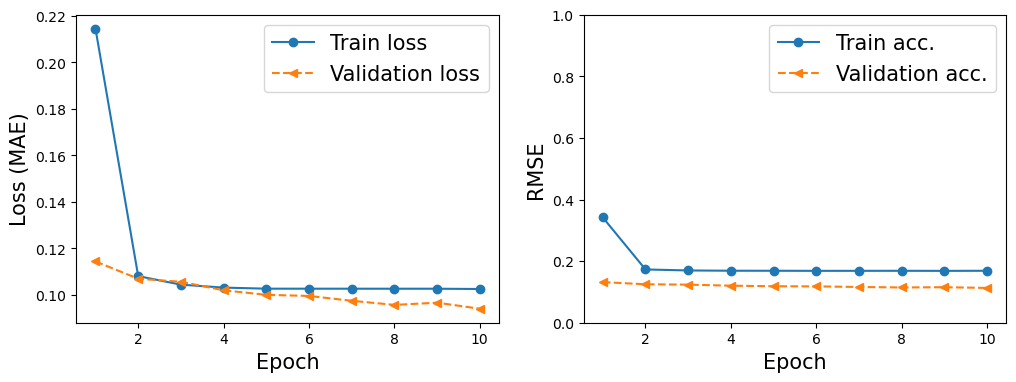

In [77]:
hist = history_V1.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss (MAE)', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['rmse'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_rmse'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('RMSE', size=15)
ax.set_ylim(0,1)
plt.show()

In [67]:
#Build the model
model_V2 = build_model( (21,8) , 21, 2, 256, 0.1,3, 1e-3)

# Fit the model.
history_V2 = model_V2.fit(
  train_dataset_V2,          # corresponding binary labels
  epochs=100,             # number of passes through the training data
  validation_data=val_dataset_V2, # use a fraction of the examples for validation
  verbose=1,             # display some progress output during training
  callbacks = [early_stopping]
  )

model_V2.summary()

Epoch 1/100
    992/Unknown 110s 94ms/step - loss: 0.1828 - mae: 0.3055 - r_squared: -13.7380 - rmse: 0.4102

C:\Users\diviveiros\AppData\Local\anaconda3\envs\mids_ml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


992/992 ━━━━━━━━━━━━━━━━━━━━ 126s 110ms/step - loss: 0.0885 - mae: 0.2093 - r_squared: -2.1614 - rmse: 0.2975 - val_loss: 0.0142 - val_mae: 0.1023 - val_r_squared: -0.4839 - val_rmse: 0.1190
Epoch 2/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 92s 90ms/step - loss: 0.0194 - mae: 0.1002 - r_squared: 0.3052 - rmse: 0.1395 - val_loss: 0.0157 - val_mae: 0.1092 - val_r_squared: -0.6437 - val_rmse: 0.1252
Epoch 3/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 85s 83ms/step - loss: 0.0150 - mae: 0.0856 - r_squared: 0.4652 - rmse: 0.1223 - val_loss: 0.0172 - val_mae: 0.1153 - val_r_squared: -0.7975 - val_rmse: 0.1310
Epoch 4/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 93s 90ms/step - loss: 0.0137 - mae: 0.0813 - r_squared: 0.5123 - rmse: 0.1168 - val_loss: 0.0188 - val_mae: 0.1220 - val_r_squared: -0.9751 - val_rmse: 0.1373
Epoch 5/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 154s 152ms/step - loss: 0.0129 - mae: 0.0783 - r_squared: 0.5405 - rmse: 0.1134 - val_loss: 0.0178 - val_mae: 0.1180 - val_r_squared: -0.8683 - val_rmse: 0.1335
Epoch 7

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [68]:
# Evaluate the model on the test set
test_results = model_V2.evaluate(test_dataset_V2, verbose=1)

144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0255 - mae: 0.1191 - r_squared: -0.0807 - rmse: 0.1597


In [79]:
#Build the model
model_V2 = build_model( (21,8) , 21, 4, 256, 0.1,3, 1e-3)

# Fit the model.
history_V2 = model_V2.fit(
  train_dataset_V2,          # corresponding binary labels
  epochs=100,             # number of passes through the training data
  validation_data=val_dataset_V2, # use a fraction of the examples for validation
  verbose=1,             # display some progress output during training
  callbacks = [early_stopping]
  )

model_V2.summary()

Epoch 1/100
    992/Unknown 752s 613ms/step - loss: 0.1501 - mae: 0.2765 - r_squared: -11.3504 - rmse: 0.3714

C:\Users\diviveiros\AppData\Local\anaconda3\envs\mids_ml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


992/992 ━━━━━━━━━━━━━━━━━━━━ 786s 648ms/step - loss: 0.0749 - mae: 0.1938 - r_squared: -1.6771 - rmse: 0.2737 - val_loss: 0.0225 - val_mae: 0.1345 - val_r_squared: -1.3589 - val_rmse: 0.1500
Epoch 2/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 321s 290ms/step - loss: 0.0180 - mae: 0.0960 - r_squared: 0.3558 - rmse: 0.1343 - val_loss: 0.0217 - val_mae: 0.1315 - val_r_squared: -1.2754 - val_rmse: 0.1474
Epoch 3/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 260s 258ms/step - loss: 0.0151 - mae: 0.0855 - r_squared: 0.4593 - rmse: 0.1230 - val_loss: 0.0221 - val_mae: 0.1326 - val_r_squared: -1.3155 - val_rmse: 0.1487
Epoch 4/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 208s 205ms/step - loss: 0.0136 - mae: 0.0810 - r_squared: 0.5150 - rmse: 0.1165 - val_loss: 0.0225 - val_mae: 0.1340 - val_r_squared: -1.3554 - val_rmse: 0.1499
Epoch 5/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 246s 224ms/step - loss: 0.0133 - mae: 0.0801 - r_squared: 0.5264 - rmse: 0.1151 - val_loss: 0.0212 - val_mae: 0.1291 - val_r_squared: -1.2177 - val_rmse: 0.1455
E

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 21, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 8)     │      4,418 │ Input[0][0],      │
│ (MultiHeadAttentio… │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_87          │ (None, 21, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 8)     │         16 │ dropout_87[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_35 (Add)        │ (None, 21, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 21, 256)   │      2,304 │ add_35[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 21, 8)     │      2,056 │ dense_52[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_88          │ (None, 21, 8)     │          0 │ dense_53[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 21, 8)     │          0 │ dropout_88[0][0], │
│                     │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 8)     │         16 │ add_36[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 8)     │      4,418 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_90          │ (None, 21, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 8)     │         16 │ dropout_90[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 21, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 21, 256)   │      2,304 │ add_37[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 21, 8)     │      2,056 │ dense_54[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_91          │ (None, 21, 8)     │          0 │ dense_55[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_38 (Add)        │ (None, 21, 8)     │          0 │ dropout_91[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 79,799 (311.72 KB)

 Trainable params: 26,599 (103.90 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 53,200 (207.82 KB)

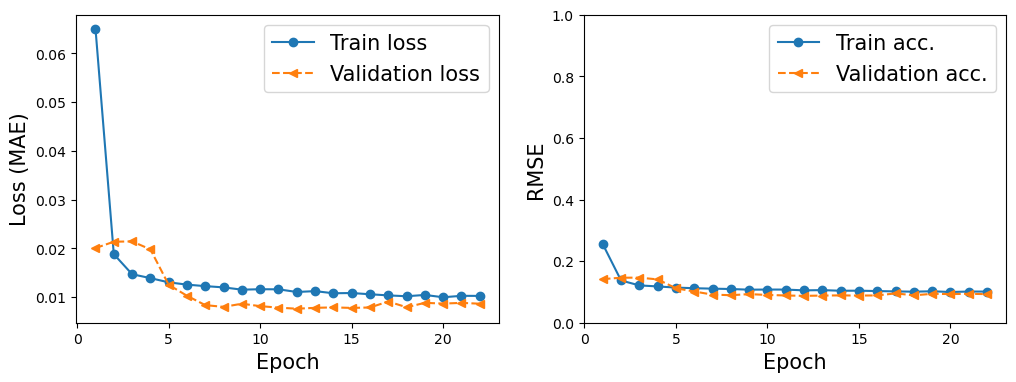

In [75]:
hist = history_V2.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss (MAE)', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['rmse'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_rmse'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('RMSE', size=15)
ax.set_ylim(0,1)
plt.show()

In [80]:
# Evaluate the model on the test set
test_results = model_V2.evaluate(test_dataset_V2, verbose=1)

144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - loss: 0.0348 - mae: 0.1571 - r_squared: -0.4731 - rmse: 0.1864
